In [1]:
# Comprehensive EDA for analysis_dataset.csv

from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
# ---------- Load data ----------
candidate_paths = [
    Path("analysis_dataset.csv"),
    Path("Data Analysis/analysis_dataset.csv"),
    Path("/Users/muneebahmed/Projects/ReSpace-AI/Data Analysis/analysis_dataset.csv"),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("analysis_dataset.csv not found in expected locations.")

df = pd.read_csv(csv_path, parse_dates=["processed_at"])
print(f"Loaded: {csv_path} | shape={df.shape}")
display(df.head(3))

Loaded: analysis_dataset.csv | shape=(1256, 13)


,id,original_id,room_type,color_theme,use_case,lighting,color_palette,furniture,status,aug_type,processed_at,image_url,local_path
0,b81eedcb-35d4-4cb0-be49-54a1be6acdf7,7ce8eccf-fd64-49eb-85c7-c7b51e143feb,Kitchen,Modern White,Modern Minimalist,Warm Indoor Lighting,Neutral,"Table, Chair, Lighting Fixtures, Plants",submitted,scaled_crop,2026-04-06 10:28:10.477242+00:00,00000014_scaled_crop.jpg,examples/dataset/images/scaled_crop_0000_00000...
1,4162d611-8aa9-4cb4-8fe6-68138bbf30be,7ce8eccf-fd64-49eb-85c7-c7b51e143feb,Kitchen,Modern White,Modern Minimalist,Warm Indoor Lighting,Neutral,"Table, Chair, Lighting Fixtures, Plants",submitted,horizontal_flip,2026-04-06 10:28:11.091093+00:00,00000014_horizontal_flip.jpg,examples/dataset/images/horizontal_flip_0001_0...
2,b03b8a27-8704-4a7c-99a2-78940af94f53,d2d840ff-5762-42e4-98c8-737bab4c133f,Lounge,Modern White,Cozy Family,Warm Indoor Lighting,Neutral,"Table, Chair, Lighting Fixtures, Plants",submitted,scaled_crop,2026-04-06 10:28:12.909282+00:00,00000015_scaled_crop.jpg,examples/dataset/images/scaled_crop_0002_00000...


In [3]:
# ---------- Basic quality checks ----------
print("\n--- Basic Data Quality ---")
print(df.info())

missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing values per column:")
display(missing.to_frame("missing_count"))

print("\nDuplicate checks:")
print("Duplicate id:", df["id"].duplicated().sum())
print("Duplicate original_id:", df["original_id"].duplicated().sum())
print("Duplicate image_url:", df["image_url"].duplicated().sum())
print("Duplicate local_path:", df["local_path"].duplicated().sum())

# Augmentation completeness per original sample
aug_per_original = df.groupby("original_id")["aug_type"].nunique().sort_values()
print("\nAugmentation types per original_id (value counts):")
display(aug_per_original.value_counts().sort_index().to_frame("num_original_ids"))


--- Basic Data Quality ---
<class 'pandas.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   id             1256 non-null   str                
 1   original_id    1256 non-null   str                
 2   room_type      1256 non-null   str                
 3   color_theme    1256 non-null   str                
 4   use_case       1256 non-null   str                
 5   lighting       1256 non-null   str                
 6   color_palette  1256 non-null   str                
 7   furniture      1256 non-null   str                
 8   status         1256 non-null   str                
 9   aug_type       1256 non-null   str                
 10  processed_at   1256 non-null   datetime64[us, UTC]
 11  image_url      1256 non-null   str                
 12  local_path     1256 non-null   str                
dtypes: datetime64[us, UTC](1), str(

,missing_count
id,0
original_id,0
room_type,0
color_theme,0
use_case,0
lighting,0
color_palette,0
furniture,0
status,0
aug_type,0



Duplicate checks:
Duplicate id: 0
Duplicate original_id: 628
Duplicate image_url: 0
Duplicate local_path: 0

Augmentation types per original_id (value counts):


,num_original_ids
aug_type,
2,628


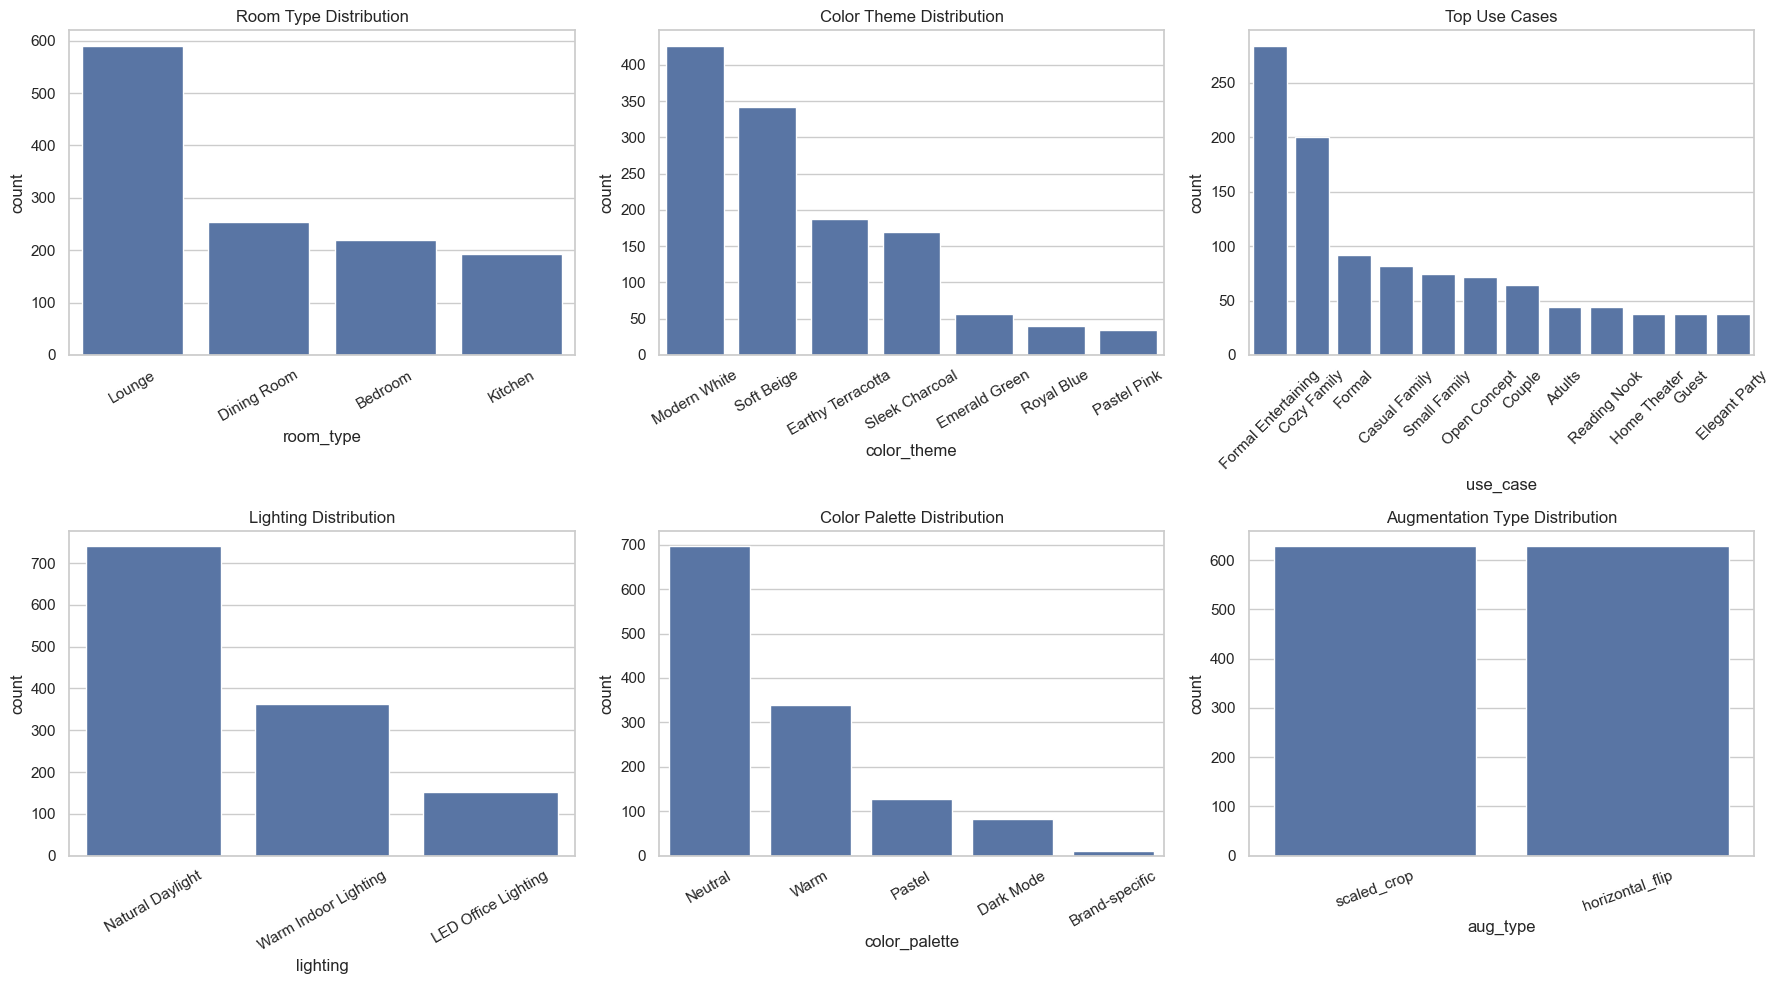

In [4]:
# ---------- High-level distributions ----------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.countplot(data=df, x="room_type", order=df["room_type"].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title("Room Type Distribution")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="color_theme", order=df["color_theme"].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title("Color Theme Distribution")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="use_case", order=df["use_case"].value_counts().index[:12], ax=axes[0, 2])
axes[0, 2].set_title("Top Use Cases")
axes[0, 2].tick_params(axis="x", rotation=45)

sns.countplot(data=df, x="lighting", order=df["lighting"].value_counts().index, ax=axes[1, 0])
axes[1, 0].set_title("Lighting Distribution")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="color_palette", order=df["color_palette"].value_counts().index, ax=axes[1, 1])
axes[1, 1].set_title("Color Palette Distribution")
axes[1, 1].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="aug_type", order=df["aug_type"].value_counts().index, ax=axes[1, 2])
axes[1, 2].set_title("Augmentation Type Distribution")
axes[1, 2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

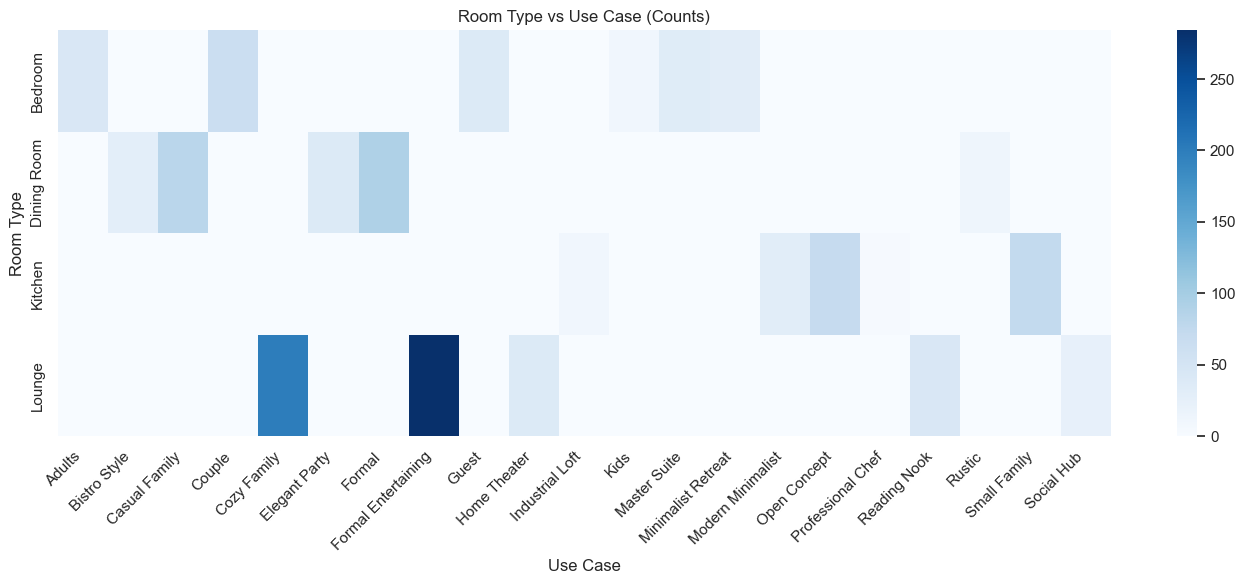

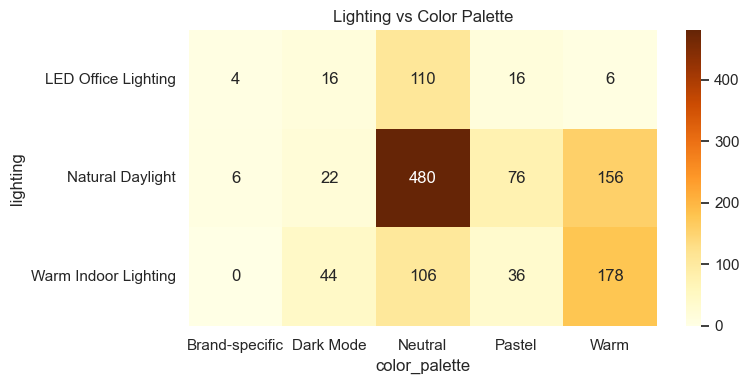

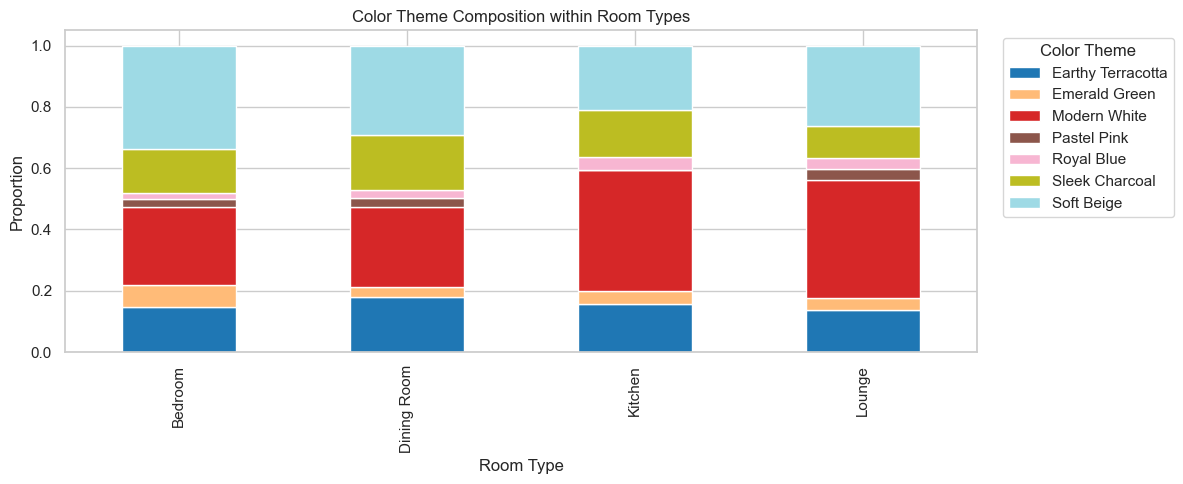

In [5]:
# ---------- Cross-category analysis ----------
room_use = pd.crosstab(df["room_type"], df["use_case"])
plt.figure(figsize=(14, 6))
sns.heatmap(room_use, cmap="Blues", annot=False)
plt.title("Room Type vs Use Case (Counts)")
plt.ylabel("Room Type")
plt.xlabel("Use Case")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

light_palette = pd.crosstab(df["lighting"], df["color_palette"])
plt.figure(figsize=(8, 4))
sns.heatmap(light_palette, cmap="YlOrBr", annot=True, fmt="d")
plt.title("Lighting vs Color Palette")
plt.tight_layout()
plt.show()

# Normalized stacked composition: room_type by color_theme
room_color = pd.crosstab(df["room_type"], df["color_theme"], normalize="index")
room_color.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab20")
plt.title("Color Theme Composition within Room Types")
plt.ylabel("Proportion")
plt.xlabel("Room Type")
plt.legend(title="Color Theme", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

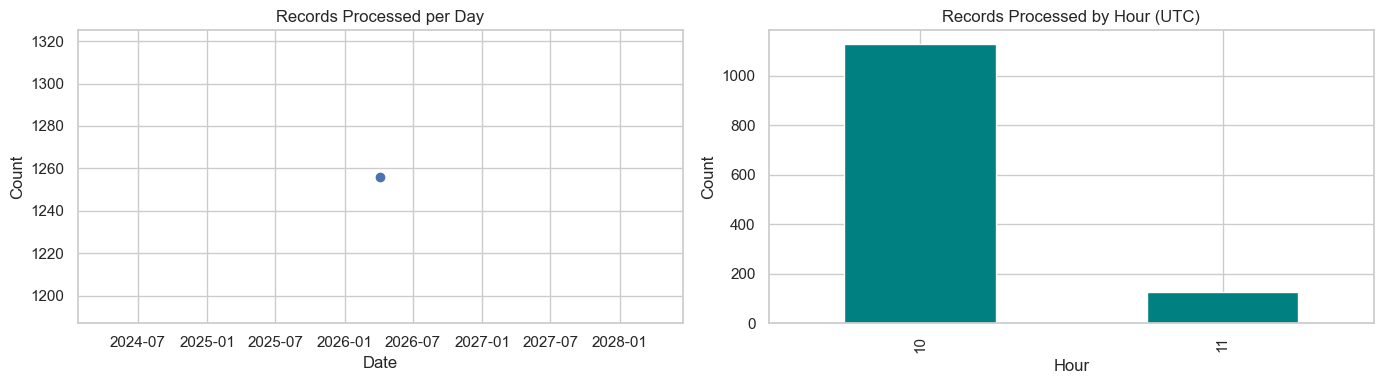

In [6]:
# ---------- Time analysis ----------
df["processed_date"] = df["processed_at"].dt.date
df["processed_hour"] = df["processed_at"].dt.hour

daily = df.groupby("processed_date").size()
hourly = df.groupby("processed_hour").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
daily.plot(ax=axes[0], marker="o")
axes[0].set_title("Records Processed per Day")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Count")

hourly.plot(kind="bar", ax=axes[1], color="teal")
axes[1].set_title("Records Processed by Hour (UTC)")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

/var/folders/5_/mp6z6lt119vcfpgmc5y9l_wh0000gn/T/ipykernel_5860/2329334694.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_furniture.values, y=top_furniture.index, palette="viridis")


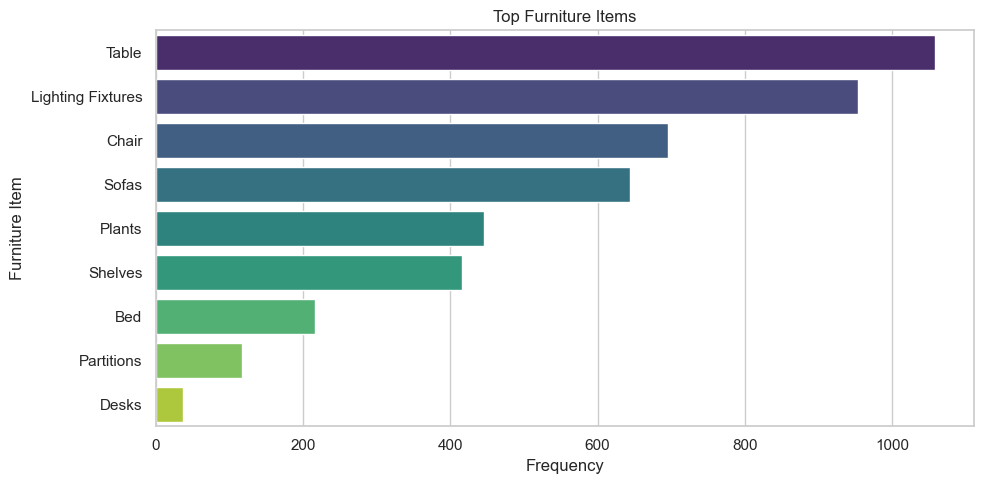

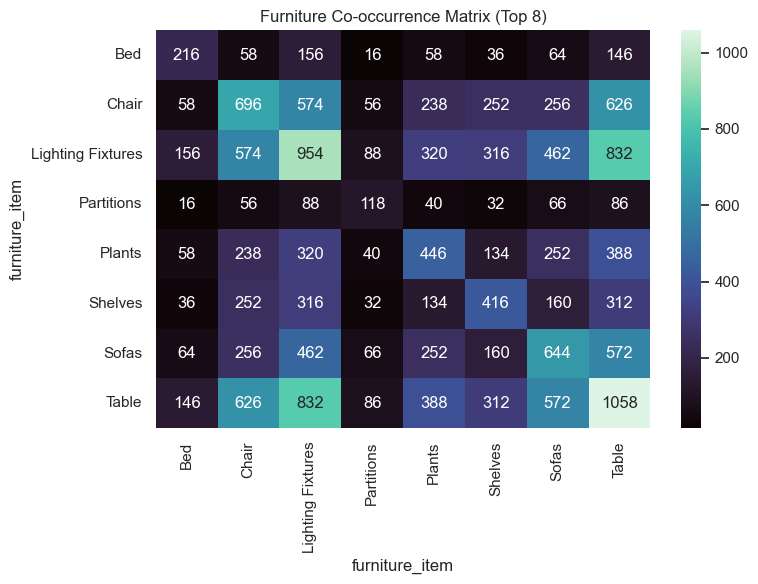

In [7]:
# ---------- Furniture analysis ----------
# Split furniture list into normalized rows
furniture_long = (
    df.assign(furniture_item=df["furniture"].fillna("").str.split(","))
      .explode("furniture_item")
)
furniture_long["furniture_item"] = furniture_long["furniture_item"].str.strip()
furniture_long = furniture_long[furniture_long["furniture_item"] != ""]

top_furniture = furniture_long["furniture_item"].value_counts().head(12)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_furniture.values, y=top_furniture.index, palette="viridis")
plt.title("Top Furniture Items")
plt.xlabel("Frequency")
plt.ylabel("Furniture Item")
plt.tight_layout()
plt.show()

# Furniture co-occurrence for top 8 items
top_items = set(furniture_long["furniture_item"].value_counts().head(8).index)
binary = (
    furniture_long[furniture_long["furniture_item"].isin(top_items)]
    .assign(v=1)
    .pivot_table(index="id", columns="furniture_item", values="v", aggfunc="max", fill_value=0)
)
co_occ = binary.T.dot(binary)
plt.figure(figsize=(8, 6))
sns.heatmap(co_occ, annot=True, fmt="d", cmap="mako")
plt.title("Furniture Co-occurrence Matrix (Top 8)")
plt.tight_layout()
plt.show()

In [8]:
# ---------- Useful summary tables ----------
print("\nTop (room_type, use_case, color_theme) combinations:")
top_combo = (
    df.groupby(["room_type", "use_case", "color_theme"])
      .size()
      .sort_values(ascending=False)
      .head(15)
      .rename("count")
      .reset_index()
)
display(top_combo)

print("\nStatus distribution:")
display(df["status"].value_counts().to_frame("count"))


Top (room_type, use_case, color_theme) combinations:


,room_type,use_case,color_theme,count
0,Lounge,Formal Entertaining,Modern White,122
1,Lounge,Formal Entertaining,Soft Beige,82
2,Lounge,Cozy Family,Modern White,76
3,Lounge,Cozy Family,Soft Beige,56
4,Lounge,Formal Entertaining,Earthy Terracotta,34
5,Dining Room,Formal,Modern White,32
6,Kitchen,Small Family,Modern White,28
7,Kitchen,Open Concept,Modern White,28
8,Dining Room,Casual Family,Modern White,28
9,Lounge,Cozy Family,Earthy Terracotta,28



Status distribution:


,count
status,
submitted,1256


# Extended Analysis

In [9]:
# ---------- Category balance (Shannon entropy) ----------
# High entropy = well-balanced; low entropy = dominated by a few values
from scipy.stats import entropy as scipy_entropy

cat_cols = ["room_type", "color_theme", "color_palette", "use_case", "lighting", "aug_type"]

balance_rows = []
for col in cat_cols:
    counts = df[col].value_counts(normalize=True)
    max_entropy = np.log(len(counts))  # entropy of a perfectly uniform distribution
    h = scipy_entropy(counts)
    balance_rows.append({
        "column": col,
        "unique_values": len(counts),
        "shannon_entropy": round(h, 4),
        "max_entropy": round(max_entropy, 4),
        "balance_pct": round(100 * h / max_entropy, 1) if max_entropy > 0 else 100.0,
        "dominant_value": counts.idxmax(),
        "dominant_pct": round(100 * counts.max(), 1),
    })

balance_df = pd.DataFrame(balance_rows).sort_values("balance_pct", ascending=True)
display(balance_df.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d9534f" if v < 50 else "#f0ad4e" if v < 75 else "#5cb85c" for v in balance_df["balance_pct"]]
ax.barh(balance_df["column"], balance_df["balance_pct"], color=colors)
ax.axvline(50, color="gray", linestyle="--", linewidth=0.8, label="50% threshold")
ax.axvline(75, color="navy", linestyle="--", linewidth=0.8, label="75% threshold")
ax.set_xlabel("Balance % (Shannon entropy / max entropy)")
ax.set_title("Category Balance Score per Feature")
ax.set_xlim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'scipy'

In [10]:
# ---------- Cramér's V correlation matrix (categorical association) ----------
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    denom = min(rcorr - 1, kcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else 0.0

assoc_cols = ["room_type", "color_theme", "color_palette", "use_case", "lighting"]
v_matrix = pd.DataFrame(index=assoc_cols, columns=assoc_cols, dtype=float)

for c1 in assoc_cols:
    for c2 in assoc_cols:
        v_matrix.loc[c1, c2] = cramers_v(df[c1], df[c2])

plt.figure(figsize=(8, 6))
sns.heatmap(
    v_matrix.astype(float),
    annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1,
    linewidths=0.5
)
plt.title("Cramér's V Association Matrix\n(0 = no association, 1 = perfect association)")
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'scipy'

/var/folders/5_/mp6z6lt119vcfpgmc5y9l_wh0000gn/T/ipykernel_5860/2017510468.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


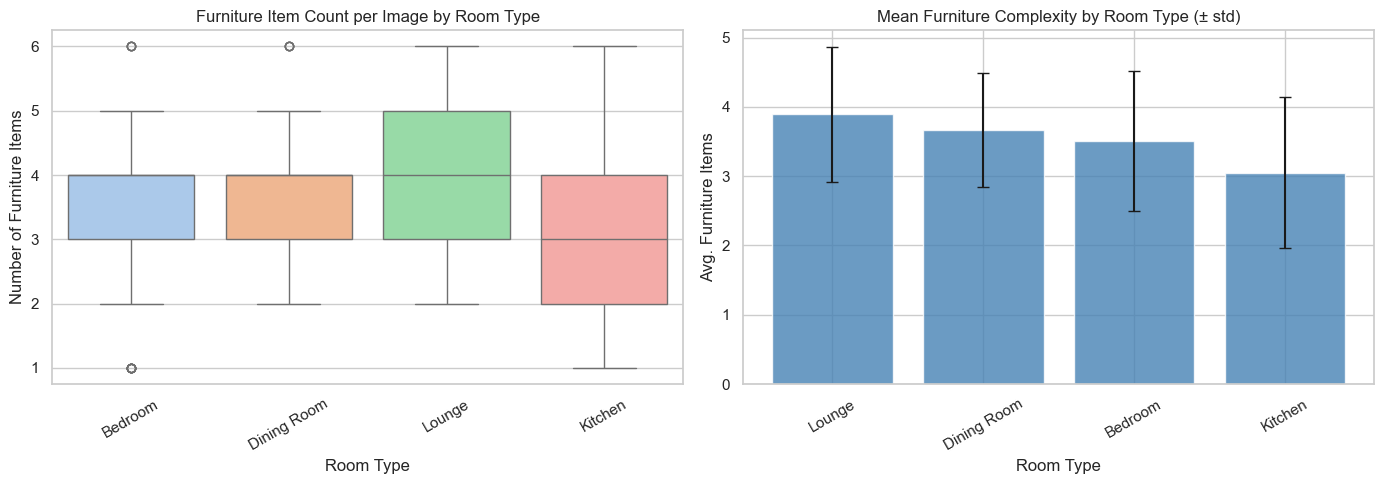

Summary stats:


,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Lounge,590.0,3.89,0.97,2.0,3.0,4.0,5.0,6.0
Dining Room,254.0,3.67,0.83,2.0,3.0,4.0,4.0,6.0
Bedroom,220.0,3.51,1.01,1.0,3.0,4.0,4.0,6.0
Kitchen,192.0,3.05,1.10,1.0,2.0,3.0,4.0,6.0


In [11]:
# ---------- Furniture complexity by room type ----------
# Count how many furniture items each image has, then compare across room types

furniture_counts = (
    df.assign(
        item_count=df["furniture"]
            .fillna("")
            .str.split(",")
            .apply(lambda lst: sum(1 for x in lst if x.strip()))
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: distribution of item count per room type
order = (
    furniture_counts.groupby("room_type")["item_count"]
    .median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(
    data=furniture_counts, x="room_type", y="item_count",
    order=order, palette="pastel", ax=axes[0]
)
axes[0].set_title("Furniture Item Count per Image by Room Type")
axes[0].set_xlabel("Room Type")
axes[0].set_ylabel("Number of Furniture Items")
axes[0].tick_params(axis="x", rotation=30)

# Mean complexity bar chart
mean_complexity = (
    furniture_counts.groupby("room_type")["item_count"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
    .reset_index()
)
axes[1].bar(mean_complexity["room_type"], mean_complexity["mean"],
            yerr=mean_complexity["std"], capsize=4, color="steelblue", alpha=0.8)
axes[1].set_title("Mean Furniture Complexity by Room Type (± std)")
axes[1].set_xlabel("Room Type")
axes[1].set_ylabel("Avg. Furniture Items")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Summary stats:")
display(
    furniture_counts.groupby("room_type")["item_count"]
    .describe()
    .round(2)
    .sort_values("mean", ascending=False)
)

Combinations with <= 3 examples: 74 / 190 total combos
These cover 148 images (11.8% of dataset)

Rarest combinations (most in need of more data):


,room_type,use_case,color_theme,lighting,count
0,Kitchen,Industrial Loft,Modern White,Natural Daylight,2
1,Kitchen,Open Concept,Sleek Charcoal,LED Office Lighting,2
2,Kitchen,Open Concept,Soft Beige,LED Office Lighting,2
3,Kitchen,Professional Chef,Earthy Terracotta,Natural Daylight,2
4,Dining Room,Casual Family,Pastel Pink,Warm Indoor Lighting,2
5,Kitchen,Professional Chef,Modern White,LED Office Lighting,2
6,Kitchen,Small Family,Sleek Charcoal,LED Office Lighting,2
7,Kitchen,Small Family,Sleek Charcoal,Warm Indoor Lighting,2
8,Dining Room,Bistro Style,Royal Blue,Warm Indoor Lighting,2
9,Dining Room,Bistro Style,Royal Blue,Natural Daylight,2


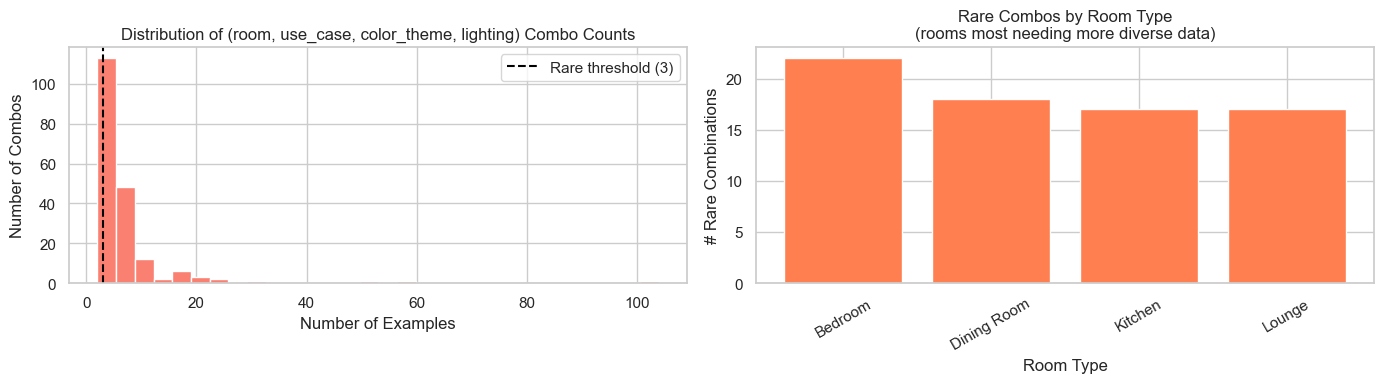

In [12]:
# ---------- Rare combination detection ----------
# Identify underrepresented (room_type, use_case, color_theme, lighting) combos
# that need more data for balanced ML training

combo_cols = ["room_type", "use_case", "color_theme", "lighting"]
combo_counts = (
    df.groupby(combo_cols)
      .size()
      .reset_index(name="count")
      .sort_values("count")
)

rare_threshold = 3
rare = combo_counts[combo_counts["count"] <= rare_threshold]
print(f"Combinations with <= {rare_threshold} examples: {len(rare)} / {len(combo_counts)} total combos")
print(f"These cover {rare['count'].sum()} images ({100*rare['count'].sum()/len(df):.1f}% of dataset)\n")

print("Rarest combinations (most in need of more data):")
display(rare.head(25).reset_index(drop=True))

# Distribution of combo counts (long tail visualization)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(combo_counts["count"], bins=30, color="salmon", edgecolor="white")
axes[0].axvline(rare_threshold, color="black", linestyle="--", label=f"Rare threshold ({rare_threshold})")
axes[0].set_title("Distribution of (room, use_case, color_theme, lighting) Combo Counts")
axes[0].set_xlabel("Number of Examples")
axes[0].set_ylabel("Number of Combos")
axes[0].legend()

# Top room types most affected by rarity
rare_by_room = (
    rare.groupby("room_type")["count"]
    .agg(rare_combos="count", total_rare_images="sum")
    .sort_values("rare_combos", ascending=False)
    .reset_index()
)
axes[1].bar(rare_by_room["room_type"], rare_by_room["rare_combos"], color="coral")
axes[1].set_title("Rare Combos by Room Type\n(rooms most needing more diverse data)")
axes[1].set_xlabel("Room Type")
axes[1].set_ylabel("# Rare Combinations")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()